In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
print("✅ All imports successful")

✅ All imports successful


In [2]:
df = pd.read_csv('data/multimodal_dementia_dataset.csv')

# Safety checks
# 24 features (clinical 4 + mri 2 + speech 18) + Subject_ID + Label = 26 columns.
# Row count is no longer fixed at 225 (real windowed match, re-runnable) -- check shape[1] only.
assert df.shape[1] == 26, f"Unexpected column count: {df.shape[1]}"
assert df.isnull().sum().sum() == 0, "NaNs found in dataset!"
assert df['Label'].isin([0, 1]).all(), "Invalid labels found!"

print(f"Dataset loaded: {df.shape}")
print(f"Label distribution:\n{df['Label'].value_counts()}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: (233, 26)
Label distribution:
Label
1    128
0    105
Name: count, dtype: int64
Columns: ['Subject_ID', 'MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV', 'pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'Label']


In [3]:
MFCC_COLS = [f'mfcc_{i}' for i in range(1, 14)]

SPEECH_FEATURES = [
    'pause_rate',
    'speech_rate',
    'pitch_mean',
    'jitter',
    'shimmer'
] + MFCC_COLS

print(f"Total speech features: {len(SPEECH_FEATURES)}")
print(f"Features: {SPEECH_FEATURES}")

print("\n=== SPEECH FEATURE OVERVIEW ===")
print(df[SPEECH_FEATURES[:5]].describe().round(4))

print("\n=== PER-CLASS MEANS ===")
print(
    df.groupby('Label')[['pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer']].mean().round(4)
)

Total speech features: 18
Features: ['pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13']

=== SPEECH FEATURE OVERVIEW ===
       pause_rate  speech_rate  pitch_mean    jitter   shimmer
count    233.0000     233.0000    233.0000  233.0000  233.0000
mean       0.2004       5.9784    146.3055    0.0485    0.1765
std        0.0002       1.0372     37.4106    0.0091    0.0272
min        0.1996       3.1000     70.7571    0.0247    0.0692
25%        0.2004       5.3667    118.5689    0.0426    0.1584
50%        0.2004       6.0667    149.9783    0.0485    0.1752
75%        0.2004       6.6667    170.9861    0.0534    0.1991
max        0.2015       8.3667    304.7896    0.0727    0.2244

=== PER-CLASS MEANS ===
       pause_rate  speech_rate  pitch_mean  jitter  shimmer
Label                                                      
0          0.2004   

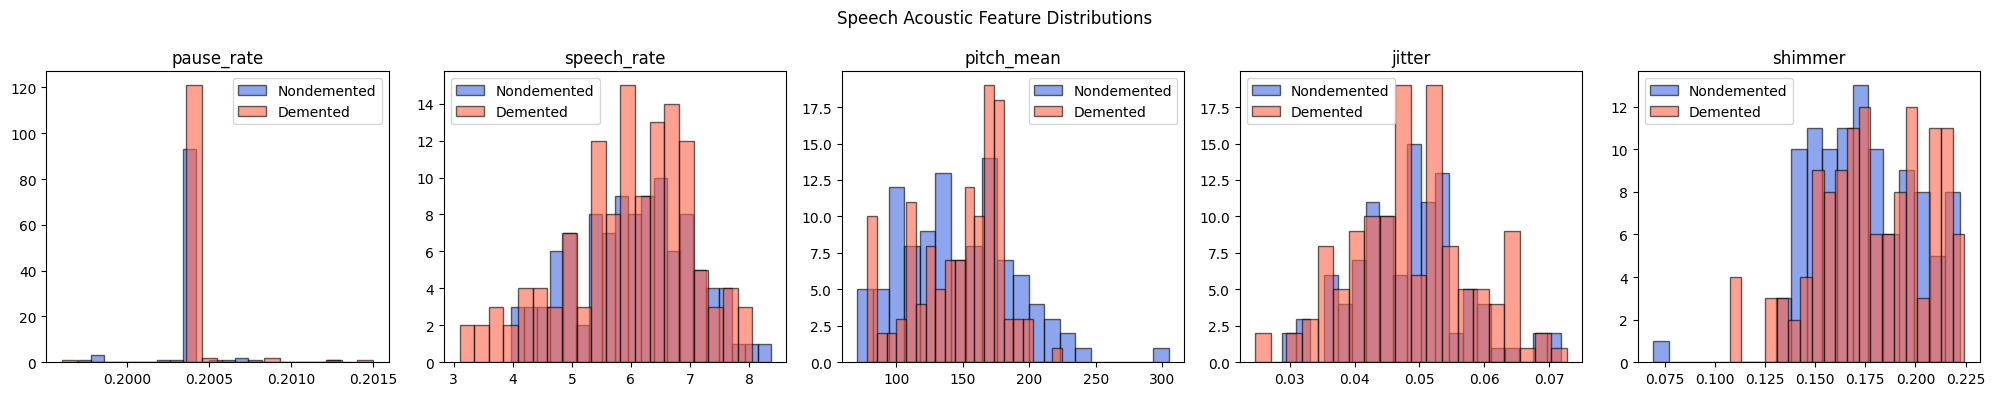

Saved plot → results/plots/speech_feature_distributions.png


In [4]:
acoustic_feats = ['pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

colors = {0: 'royalblue', 1: 'tomato'}
labels = {0: 'Nondemented', 1: 'Demented'}

for ax, feat in zip(axes, acoustic_feats):
    for lbl in [0, 1]:
        ax.hist(
            df[df['Label'] == lbl][feat],
            bins=20,
            alpha=0.6,
            color=colors[lbl],
            label=labels[lbl],
            edgecolor='black'
        )
    ax.set_title(feat)
    ax.legend()

plt.suptitle("Speech Acoustic Feature Distributions")
plt.tight_layout()
plt.savefig("results/plots/speech_feature_distributions.png")
plt.show()

print("Saved plot → results/plots/speech_feature_distributions.png")

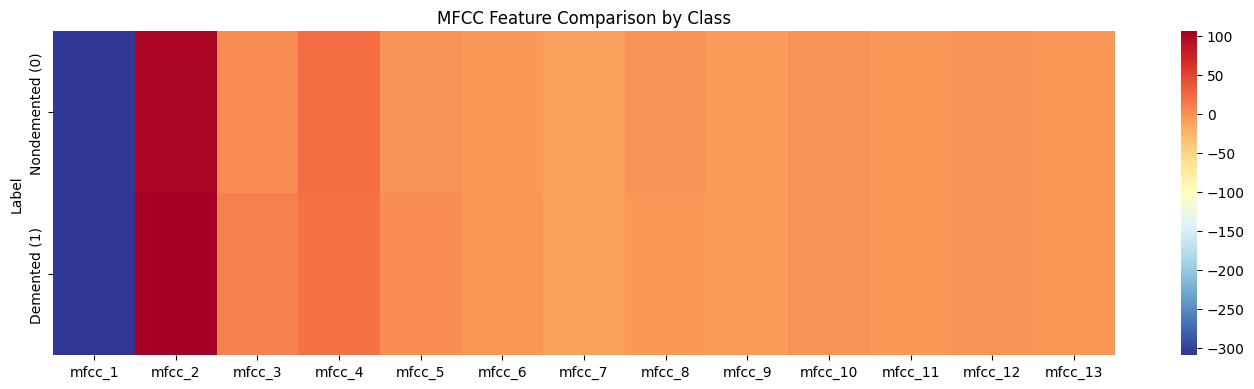

Saved plot → results/plots/mfcc_class_comparison.png


In [5]:
mfcc_means = df.groupby('Label')[MFCC_COLS].mean()

plt.figure(figsize=(14, 4))
sns.heatmap(
    mfcc_means,
    cmap='RdYlBu_r',
    yticklabels=['Nondemented (0)', 'Demented (1)']
)

plt.title("MFCC Feature Comparison by Class")
plt.tight_layout()
plt.savefig("results/plots/mfcc_class_comparison.png")
plt.show()

print("Saved plot → results/plots/mfcc_class_comparison.png")

In [6]:
X_speech = df[SPEECH_FEATURES].values
y = df['Label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_speech)

print("Shape:", X_scaled.shape)
print("Mean (approx 0):", X_scaled.mean(axis=0)[:5])
print("Std (approx 1):", X_scaled.std(axis=0)[:5])

Shape: (233, 18)
Mean (approx 0): [-2.11851519e-13  3.03048002e-16  3.04953964e-17  3.24013587e-17
 -4.26935549e-16]
Std (approx 1): [1. 1. 1. 1. 1.]


Explained variance ratio: [0.19936342 0.11586761]
Total variance retained: 0.31523103189837404
Shape: (233, 2)


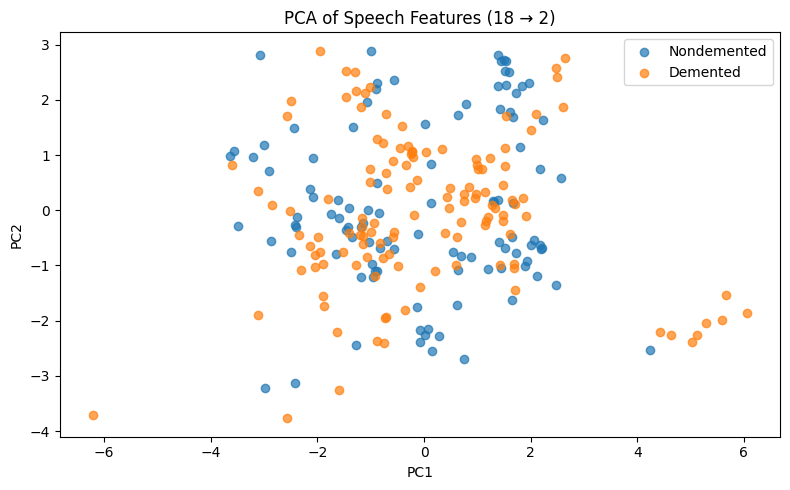

Saved plot → results/plots/speech_pca.png


In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))
print("Shape:", X_pca.shape)

plt.figure(figsize=(8, 5))

plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1],
            label="Nondemented", alpha=0.7)

plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1],
            label="Demented", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Speech Features (18 → 2)")
plt.legend()

plt.tight_layout()
plt.savefig("results/plots/speech_pca.png")
plt.show()

print("Saved plot → results/plots/speech_pca.png")

In [8]:
np.save("results/X_speech_pca.npy", X_pca)

print("Saved → results/X_speech_pca.npy")
print("Shape:", X_pca.shape)

# verification
check = np.load("results/X_speech_pca.npy")
assert check.shape[1] == 2, "Shape mismatch!"

print("✅ Verification passed")

Saved → results/X_speech_pca.npy
Shape: (233, 2)
✅ Verification passed
